<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/Autoencoder_Application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

### Project Overview
This project implements a Convolutional Autoencoder for anomaly detection on MRI images. An autoencoder is a type of artificial neural network used for learning efficient data codings (representations) in an unsupervised manner. The goal is to reconstruct the input, and by doing so, learn a lower-dimensional representation of the data. This representation can then be used for tasks like anomaly detection, where 'anomalous' images would be poorly reconstructed.

In [2]:
train_path = "/content/drive/MyDrive/dataset/MRI_Dataset/Training"
test_path = "/content/drive/MyDrive/dataset/MRI_Dataset/Testing"

### Data Paths
We define the paths for the training and testing datasets. These datasets contain MRI images organized into different classes.

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32

### Configuration
`IMG_SIZE`: Defines the target dimensions for resizing input images to 128x128 pixels. This standardization is crucial for consistent model input.
`BATCH_SIZE`: Specifies the number of samples per gradient update during training, set to 32.

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

### Image Data Generators
`ImageDataGenerator` is used for on-the-fly data augmentation and preprocessing. Here, we only apply `rescale=1./255` to normalize pixel values from [0, 255] to [0, 1]. This helps in better training of neural networks.

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='input',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='input',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


### Setup Data Generators
`flow_from_directory` creates image generators that read images from specified directories.
- `target_size`: Resizes all images to `(IMG_SIZE, IMG_SIZE)`.
- `batch_size`: Number of images to yield from the generator per batch.
- `class_mode='input'`: For autoencoders, the input and output are the same, so we set `class_mode` to 'input' which means the generator will yield batches of image data (`x`) and corresponding image data (`y`) where `x` and `y` are identical.
- `shuffle=True`: Shuffles the training data each epoch.
- `shuffle=False`: For the test set, we don't need to shuffle.

In [6]:
input_img = Input(shape=(128,128,3))

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same',name="Encoded_Layer")(x)

### Encoder Architecture
The encoder part of the autoencoder takes the input image and compresses it into a lower-dimensional representation (encoded features).
- **Input Layer**: `Input(shape=(128,128,3))` defines the input shape for images (height, width, channels).
- **Convolutional Layers (`Conv2D`)**: Extract features from the input image using filters. `activation='relu'` applies the Rectified Linear Unit activation function.
- **MaxPooling Layers (`MaxPooling2D`)**: Downsample the feature maps, reducing their spatial dimensions and making the representation more robust to small shifts.

In [7]:
x = Conv2D(128,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

### Decoder Architecture
The decoder part of the autoencoder takes the compressed (encoded) representation and reconstructs the original image.
- **Convolutional Layers (`Conv2D`)**: Similar to the encoder, these layers learn to reconstruct features.
- **UpSampling Layers (`UpSampling2D`)**: Upsample the feature maps, increasing their spatial dimensions to match the original image size.
- **Output Layer**: `Conv2D` with 3 filters (for RGB channels) and `activation='sigmoid'` to output pixel values in the range [0, 1], matching the normalized input.

In [8]:
autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoded_Layer (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### Autoencoder Diagram
```
Input Image
      │
      ▼
Conv2D (32)
      │
MaxPooling
      │
Conv2D (64)
      │
MaxPooling
      │
Conv2D (128)
      │
MaxPooling
      │
────────────────────────────
      Encoded Features
────────────────────────────
      │
Conv2D (128)
      │
UpSampling
      │
Conv2D (64)
      │
UpSampling
      │
Conv2D (32)
      │
UpSampling
      │
Conv2D (3)
      │
Output Image
```

### Autoencoder Model
We create the `autoencoder` model by connecting the input layer (`input_img`) to the final decoded output (`decoded`). The `summary()` method prints a concise summary of the model architecture, including layer names, output shapes, and the number of parameters.

In [9]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Model Compilation
- `optimizer='adam'`: The Adam optimizer is used for training, known for its efficiency and good performance in various deep learning tasks.
- `loss='binary_crossentropy'`: This loss function is suitable for pixel-wise reconstruction when pixel values are normalized between 0 and 1 (as is the case with `sigmoid` activation).
- `metrics=['accuracy']`: We monitor accuracy during training, though `binary_crossentropy` is the primary optimization target for reconstruction.

In [10]:
history = autoencoder.fit(
    train_generator,
    epochs=2,
    validation_data=test_generator
)

Epoch 1/2
175/175 ━━━━━━━━━━━━━━━━━━━━ 1586s 9s/step - accuracy: 0.3193 - loss: 0.3961 - val_accuracy: 0.3344 - val_loss: 0.3738
Epoch 2/2
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.3609 - loss: 0.3593 - val_accuracy: 0.3843 - val_loss: 0.3652


### Model Training
The `fit` method trains the autoencoder model.
- `train_generator`: Provides the training data.
- `epochs=2`: The model will iterate over the entire training dataset twice.
- `validation_data=test_generator`: The model will evaluate its performance on the test set after each epoch. The `val_accuracy` and `val_loss` metrics are reported for the validation set.

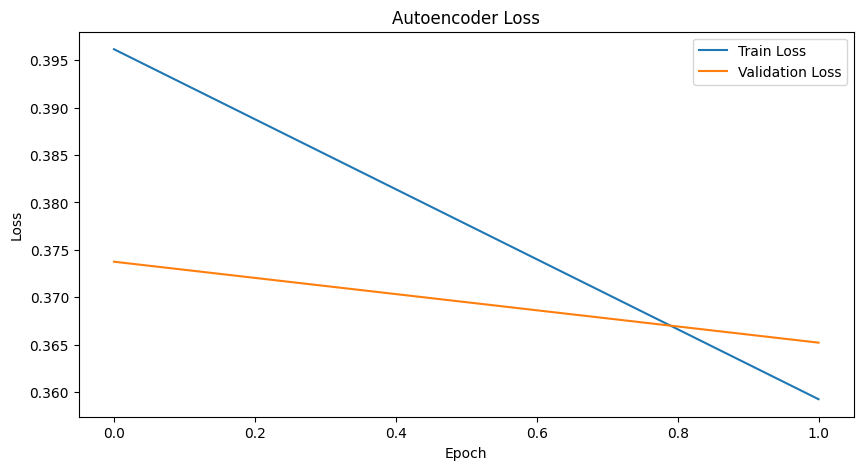

In [13]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Loss")
plt.show()

### Loss Visualization
This plot displays the training loss and validation loss over epochs. It helps in understanding if the model is learning effectively and if there's any overfitting (large gap between training and validation loss).

In [14]:
images, labels = next(test_generator)

predictions = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step


### Generate Predictions
Here, we take a batch of images from the `test_generator` and use the trained `autoencoder` model to predict their reconstructed versions. `images` will hold the original test images, and `predictions` will hold the autoencoder's reconstructed outputs.

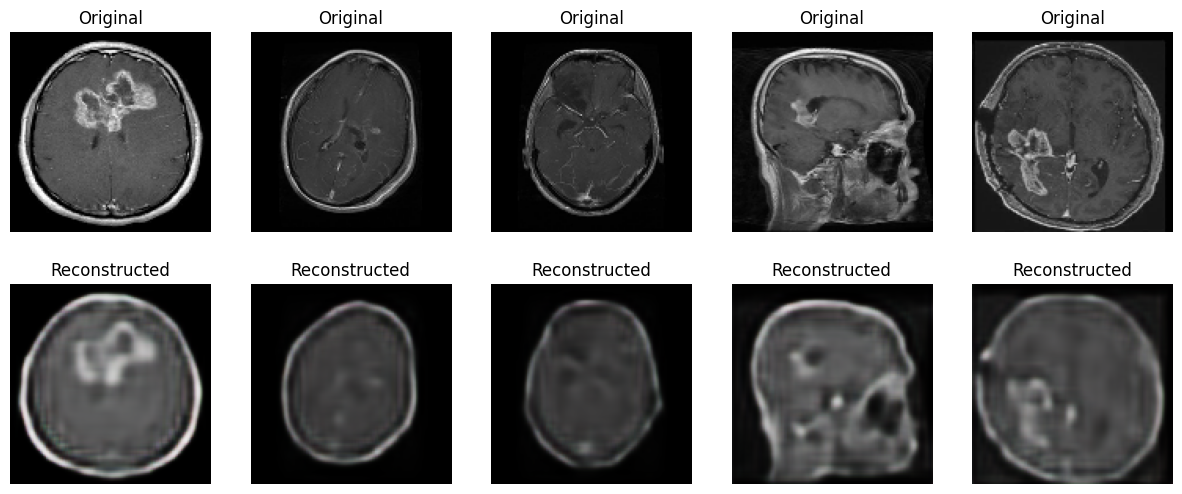

In [15]:
plt.figure(figsize=(15,6))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2,5,i+6)
    plt.imshow(predictions[i])
    plt.axis("off")
    plt.title("Reconstructed")

plt.show()

### Visualize Original vs. Reconstructed Images
This code block displays a few original test images alongside their corresponding reconstructed images from the autoencoder. This visual comparison helps to assess the quality of the autoencoder's reconstruction.

In [16]:
encoder = Model(
    autoencoder.input,
    autoencoder.get_layer("Encoded_Layer").output
)

encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoded_Layer (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

### Extract Encoder Model
We create a separate `encoder` model by taking the input of the `autoencoder` and stopping at the 'Encoded_Layer'. This allows us to extract the compressed feature representation (embeddings) for new images, which can be useful for downstream tasks like classification or anomaly detection.

In [19]:
features = encoder.predict(test_generator)

print(features.shape)

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step
(1600, 16, 16, 128)


### Extract Features
We use the extracted `encoder` model to predict (extract) the encoded features for the entire `test_generator` dataset. The `features.shape` output shows the dimensions of these extracted features: (number of samples, height, width, channels) of the encoded representation.

In [20]:
features = features.reshape(features.shape[0],-1)

print(features.shape)

(1600, 32768)


### Reshape Features
We reshape the `features` array from a 4D tensor (batch, height, width, channels) into a 2D tensor (batch, flattened_features). This flattens the spatial dimensions of the encoded representation, making it suitable for use with traditional machine learning algorithms or for similarity calculations.

In [21]:
autoencoder.save("BrainTumor_Autoencoder.keras")

### Save Autoencoder Model
This saves the entire autoencoder model (architecture, weights, and optimizer state) to a file named 'BrainTumor_Autoencoder.keras'. This allows us to load and reuse the trained model later without retraining.

In [22]:
encoder.save("BrainTumor_Encoder.keras")

### Save Encoder Model
Similarly, this saves only the encoder part of the model to 'BrainTumor_Encoder.keras'. This is useful if we only need the feature extraction capability of the encoder for future tasks.

In [23]:
img = images[0:1]

compressed = encoder.predict(img)

print(compressed.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
(1, 16, 16, 128)


### Compress a Single Image
We take a single image from the test set (`images[0:1]`) and pass it through the `encoder` to get its compressed representation. The `compressed.shape` shows the dimensions of this single image's encoded features.

In [24]:
decoder_input = Input(shape=(16,16,128))

x = autoencoder.layers[-7](decoder_input)
x = autoencoder.layers[-6](x)
x = autoencoder.layers[-5](x)
x = autoencoder.layers[-4](x)
x = autoencoder.layers[-3](x)
x = autoencoder.layers[-2](x)
decoder_output = autoencoder.layers[-1](x)

decoder = Model(decoder_input, decoder_output)

### Extract Decoder Model
To separately reconstruct an image from its compressed representation, we extract the decoder part of the autoencoder. We define a new input for the decoder (`decoder_input`) and connect it to the corresponding layers from the original `autoencoder` that constitute the decoder path. This allows us to feed compressed features directly into the decoder.

In [25]:
reconstructed = decoder.predict(compressed)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


### Reconstruct from Decoder
Finally, we use the standalone `decoder` model to reconstruct the image from the `compressed` features obtained earlier. This demonstrates that the decoder can independently convert the latent representation back into an image.